<a href="https://colab.research.google.com/github/chihway/mapping_the_universe/blob/main/Basic/Tutorial%202%20-%20Galaxy%20Catalogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 2 - Galaxy Catalogs

In this tutorial we will learn how to manipulate a galaxy catalog and make some simple plots. In this tutorial you will be able to

* read and understand what a fits file is
* read and understand what a hdf5 file is
* plot columns of the galaxy catalog
* manipulate the catalog and add new columns 
* use pandas to do some of these operations

If you already know all of this, feel free to skip to [Tutorial 3 - Galaxy Images](https://github.com/chihway/mapping_the_universe/blob/main/Basic/Tutorial%203%20-%20Galaxy%20Images.ipynb).


Here are some new python packages that are introduced in this tutorial:

* `astropy` (https://www.astropy.org/): open-source Python library designed for astrophysics research. It provides tools for performing a wide range of astronomical computations and data processing tasks. Astropy is built on top of the popular scientific Python stack (NumPy, SciPy, and matplotlib).

* `h5py` (https://www.h5py.org/): Python library that provides a simple and efficient interface to the HDF5 (Hierarchical Data Format) file format. HDF5 is a popular format for storing large amounts of numerical data, often used in scientific computing, machine learning, and data analysis.  

* `pandas` (https://pandas.pydata.org/): open-source Python library designed for data manipulation, analysis, and exploration. It provides powerful and flexible tools for working with structured data, such as tabular data in spreadsheets or databases, and is widely used in data science, machine learning, and general programming.

In [1]:
import astropy
import astropy.io.fits as pf
import numpy as np
import scipy
import matplotlib.pyplot as plt
import h5py
import pandas as pd

In [29]:
# we need to first download some files -- these are the DES Y3 deep field catalogs
# you can read about the catalog here: https://arxiv.org/abs/2012.12824
# the schema of the catalog can be found here: https://des.ncsa.illinois.edu/releases/y3a2/Y3deepfields

# once you executed this once, you can comment out these two lines
!curl -O https://portal.nersc.gov/cfs/lsst/chihway/mapping_the_universe/des_y3_deepfield.fits.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  333M  100  333M    0     0  11.8M      0  0:00:28  0:00:28 --:--:-- 11.1M  23 77.0M    0     0  13.0M      0  0:00:25  0:00:05  0:00:20 14.5M0  0:00:27  0:00:23  0:00:04 12.6M


In [2]:
# you'll need to install this package to turn the fits file to an hdf5 file
# git clone https://github.com/telegraphic/fits2hdf
# cd fits2hdf
# python setup.py install

from fits2hdf.io.fitsio import read_fits
from fits2hdf.io.hdfio import export_hdf
a = read_fits('des_y3_deepfield.fits.gz')
export_hdf(a, 'des_y3_deepfield.hdf5')

## Reading and manipulating a FITS file

For the full information, please see https://docs.astropy.org/en/stable/io/fits/index.html

In [3]:
# read the file

fitsfile = pf.open('des_y3_deepfield.fits.gz')

In [4]:
# shows how many extensions the file has, for typical catalogs, the first extension (index 0)
# is usually empty, and the catalog content starts from the second (index 1) extension
# we also see that the catalog has 2826988 rows/objects, each with 22 columns/properties

fitsfile.info()

Filename: des_y3_deepfield.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1                1 BinTableHDU     65   2826988R x 24C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K]   


In [5]:
# you can see what the catalog contains from the header

fitsfile[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                  192 / width of table in bytes                        
NAXIS2  =              2826988 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   24 / number of fields in each row                   
TTYPE1  = 'ID      '           / label for field   1                            
TFORM1  = 'K       '           / data format of field: 8-byte INTEGER           
TTYPE2  = 'RA      '           / label for field   2                            
TFORM2  = 'D       '           / data format of field: 8-byte DOUBLE            
TTYPE3  = 'DEC     '        

In [6]:
# to access the data

fitsdata = fitsfile[1].data

In [7]:
# apply some basic masks to remove non-galaxy and other bad objects

mask = (fitsdata['KNN_CLASS']==1)*(fitsdata['FLAGS']==0)*(fitsdata['FLAGS_NIR']==0) \
                    *(fitsdata['MASK_FLAGS']==0)*(fitsdata['MASK_FLAGS_NIR']==0)

print('Number of objects after cuts:', len(fitsdata['RA'][mask]))

Number of objects after cuts: 1431620


Text(0.5, 0, 'Dec')

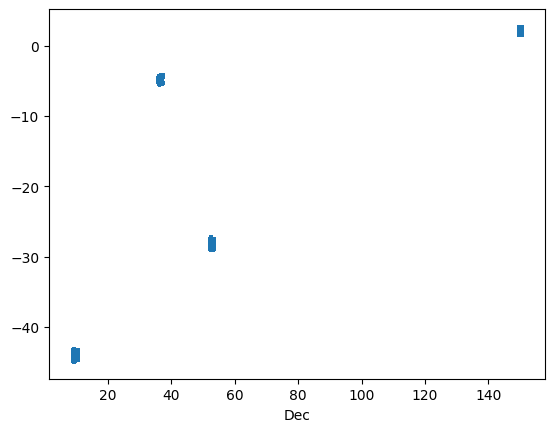

In [8]:
# plot the RA/DEC of the remaining objects to see where they are
# these are the 4 areas that cover the 10 deep fields: CDFS (SN-C1, SN-C2, SN-C3), 
# Elais-South (SN-E1, SN-E2), Stripe 82 (SN-S1, SN-S2) and XMM-LSS (SN-X1, SN-X2, SN-X3)

plt.scatter(fitsdata['RA'][mask], fitsdata['DEC'][mask], s=1)
plt.xlabel('RA')
plt.xlabel('Dec')

Text(0.5, 0, 'Dec')

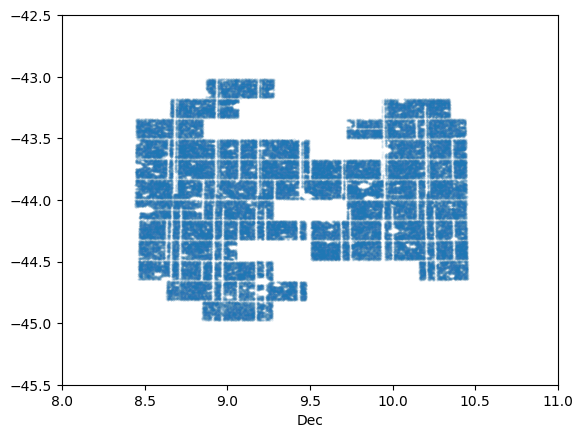

In [9]:
# zooming into one of the fields: Elais-South

plt.scatter(fitsdata['RA'][mask], fitsdata['DEC'][mask], s=0.1, alpha=0.1)
plt.xlim(8,11)
plt.ylim(-45.5,-42.5)
plt.xlabel('RA')
plt.xlabel('Dec')

/var/folders/mc/gj6kz6750g7dks2k81t8xyl80000gn/T/ipykernel_77300/2982390562.py:9: RuntimeWarning: invalid value encountered in log10
  return -2.5*np.log10(flux)+30.0


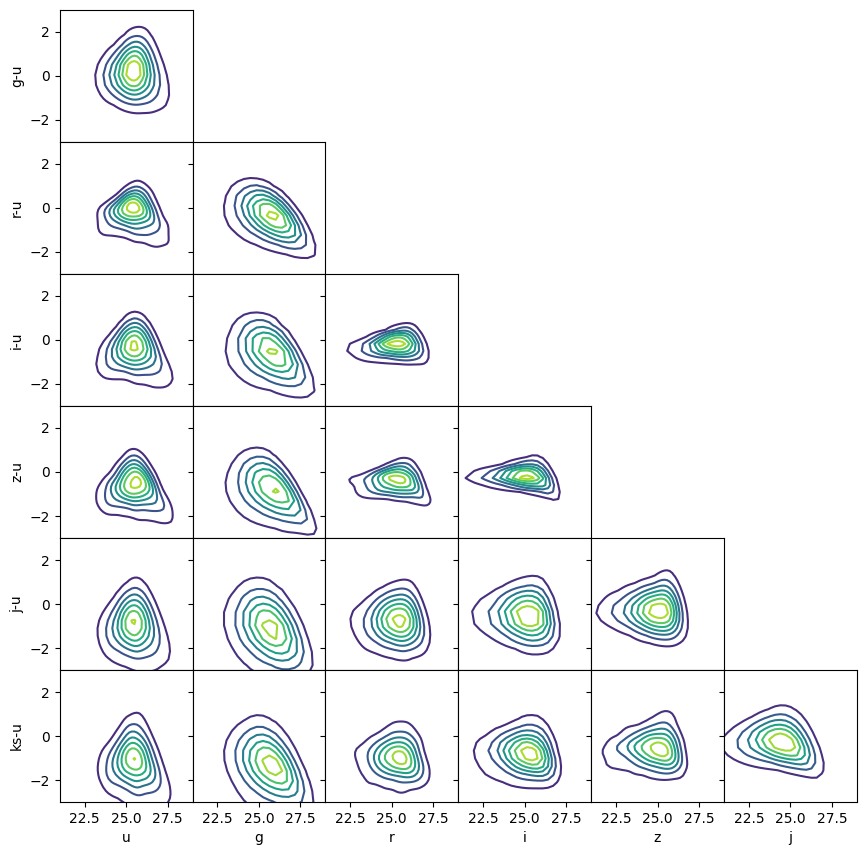

In [10]:
# make a color-magnitude plot

fitsdata_mask = fitsdata[mask][:10000]

from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec

def flux2mag(flux):
    return -2.5*np.log10(flux)+30.0

mag_u = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_U'])
mag_g = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_G'])
mag_r = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_R'])
mag_i = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_I'])
mag_z = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_Z'])
mag_j = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_J'])
mag_ks = flux2mag(fitsdata_mask['BDF_FLUX_DERED_CALIB_KS'])

mags = [mag_u,mag_g,mag_r,mag_i,mag_z,mag_j,mag_ks]
mags = np.nan_to_num(np.array(mags))
color = ['u','g','r','i','z','j','ks']
Color = ['U','G','R','I','Z','J','KS']

fig = plt.figure(figsize=(12, 12))
gs = GridSpec(7, 7, hspace=0, wspace=0)

for i in range(7):
    for j in range(7):
        if i>j:
            
            # Calculate the point density using a kernel density estimation
            xy = np.vstack([mags[j], mags[i]-mags[j]])
            kde = gaussian_kde(xy)

            # Create a grid of points for the contour plot
            X, Y = np.mgrid[mags[j].min():mags[j].max():100j, (mags[i]-mags[j]).min():(mags[i]-mags[j]).max():100j]
            positions = np.vstack([X.ravel(), Y.ravel()])

            # Evaluate the KDE on the grid
            Z = np.reshape(kde(positions).T, X.shape)

            # Create the contour plot
            ax = fig.add_subplot(gs[i, j])
            ax.contour(X, Y, Z)
            if i==6:
                ax.set_xlabel(color[j])
            else:
                ax.set_xticklabels("")
            if j==0:
                ax.set_ylabel(color[i]+'-'+color[j])
            else:
                ax.set_yticklabels("")
                
            ax.set_xlim(21,29)
            ax.set_ylim(-3,3)


In [11]:
# add a new magnitude column

table_hdu = fitsfile[1]  # Assuming the table is in the second HDU (index 1)
data = table_hdu.data

# Create a new column
new_col = data.columns
for i in range(7):
    new_col += pf.Column(name='MAG_'+str(color[i]), format='D', array=flux2mag(fitsdata['BDF_FLUX_DERED_CALIB_'+str(color[i])]))

# Combine the new column with the existing columns
new_columns = pf.ColDefs(new_col)
updated_hdu = pf.BinTableHDU.from_columns(new_columns)

# Update the HDU
fitsfile[1] = updated_hdu

# update file
fitsfile.writeto('new.fits', overwrite=True)

/var/folders/mc/gj6kz6750g7dks2k81t8xyl80000gn/T/ipykernel_77300/2982390562.py:9: RuntimeWarning: invalid value encountered in log10
  return -2.5*np.log10(flux)+30.0


In [12]:
# check that the columns are indeed added
print(pf.open('new.fits')[1].header.keys)

# check that the new columns has reasonable values
print(pf.open('new.fits')[1].data['MAG_i'])

<bound method Header.keys of XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  248 / length of dimension 1                          
NAXIS2  =              2826988 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   31 / number of table fields                         
TTYPE1  = 'ID      '                                                            
TFORM1  = 'K       '                                                            
TTYPE2  = 'RA      '                                                            
TFORM2  = 'D       '                                                            

## Reading in a hdf5 file and do the same thing

In [13]:
# check the structure of the h5 file
with h5py.File('des_y3_deepfield.hdf5','r') as f:
    print(f.keys())
    print(f['HDU0'].keys())
    print(f['HDU0/DATA'].keys())
    print(f['HDU0/DATA/RA'][:])

<KeysViewHDF5 ['HDU0', 'PRIMARY']>
<KeysViewHDF5 ['COMMENT', 'DATA', 'HISTORY']>
<KeysViewHDF5 ['BDF_FLUX_DERED_CALIB_G', 'BDF_FLUX_DERED_CALIB_H', 'BDF_FLUX_DERED_CALIB_I', 'BDF_FLUX_DERED_CALIB_J', 'BDF_FLUX_DERED_CALIB_KS', 'BDF_FLUX_DERED_CALIB_R', 'BDF_FLUX_DERED_CALIB_U', 'BDF_FLUX_DERED_CALIB_Z', 'BDF_FLUX_ERR_DERED_CALIB_G', 'BDF_FLUX_ERR_DERED_CALIB_H', 'BDF_FLUX_ERR_DERED_CALIB_I', 'BDF_FLUX_ERR_DERED_CALIB_J', 'BDF_FLUX_ERR_DERED_CALIB_KS', 'BDF_FLUX_ERR_DERED_CALIB_R', 'BDF_FLUX_ERR_DERED_CALIB_U', 'BDF_FLUX_ERR_DERED_CALIB_Z', 'DEC', 'FLAGS', 'FLAGS_NIR', 'ID', 'KNN_CLASS', 'MASK_FLAGS', 'MASK_FLAGS_NIR', 'RA']>
[ 52.22639313  52.43641176  52.18629346 ... 150.3735097  150.4827167
 150.30759158]


In [14]:
# extract data from file, note that columns of h5 files are sensitive to 
# capitalization of the names, while fits files are not

with h5py.File('des_y3_deepfield.hdf5','r') as f:
    knn_class = f['HDU0/DATA/KNN_CLASS'][:]
    flags = f['HDU0/DATA/FLAGS'][:]
    flags_nir = f['HDU0/DATA/FLAGS_NIR'][:]
    mask_flags = f['HDU0/DATA/MASK_FLAGS'][:]
    mask_flags_nir = f['HDU0/DATA/MASK_FLAGS_NIR'][:]
    
mask = (knn_class==1)*(flags==0)*(flags_nir==0)*(mask_flags==0)*(mask_flags_nir==0)

print('Number of objects after cuts:', len(flags[mask]))

Number of objects after cuts: 1431620


In [15]:
# add a column to the file
with h5py.File('des_y3_deepfield.hdf5', 'a') as f:
    for i in range(7):
        flux = f['HDU0/DATA/BDF_FLUX_DERED_CALIB_'+str(Color[i])][:]
        f.create_dataset('HDU0/DATA/MAG_'+str(Color[i]), data = flux2mag(flux))
    

/var/folders/mc/gj6kz6750g7dks2k81t8xyl80000gn/T/ipykernel_77300/2982390562.py:9: RuntimeWarning: invalid value encountered in log10
  return -2.5*np.log10(flux)+30.0


In [16]:
with h5py.File('des_y3_deepfield.hdf5','r') as f:
    print(f['HDU0/DATA'].keys())
    print(f['HDU0/DATA/MAG_R'][:])


<KeysViewHDF5 ['BDF_FLUX_DERED_CALIB_G', 'BDF_FLUX_DERED_CALIB_H', 'BDF_FLUX_DERED_CALIB_I', 'BDF_FLUX_DERED_CALIB_J', 'BDF_FLUX_DERED_CALIB_KS', 'BDF_FLUX_DERED_CALIB_R', 'BDF_FLUX_DERED_CALIB_U', 'BDF_FLUX_DERED_CALIB_Z', 'BDF_FLUX_ERR_DERED_CALIB_G', 'BDF_FLUX_ERR_DERED_CALIB_H', 'BDF_FLUX_ERR_DERED_CALIB_I', 'BDF_FLUX_ERR_DERED_CALIB_J', 'BDF_FLUX_ERR_DERED_CALIB_KS', 'BDF_FLUX_ERR_DERED_CALIB_R', 'BDF_FLUX_ERR_DERED_CALIB_U', 'BDF_FLUX_ERR_DERED_CALIB_Z', 'DEC', 'FLAGS', 'FLAGS_NIR', 'ID', 'KNN_CLASS', 'MAG_G', 'MAG_I', 'MAG_J', 'MAG_KS', 'MAG_R', 'MAG_U', 'MAG_Z', 'MASK_FLAGS', 'MASK_FLAGS_NIR', 'RA']>
[25.27929692 20.3807764  25.51158352 ... 25.10880669 24.42573198
 23.98694938]


## Now convert the fits file to a pandas frame

In [28]:
# Open the FITS file
import os
os.system('gunzip des_y3_deepfield.fits.gz')
f = pf.open('des_y3_deepfield.fits')
# Access the data from the desired HDU (e.g., the first one)
data = f[1].data

# Convert the FITS data to a pandas DataFrame
df = pd.DataFrame(data)

gunzip: can't stat: des_y3_deepfield.fits.gz (des_y3_deepfield.fits.gz.gz): No such file or directory


In [ ]:
print(df.head())